In [233]:
import os
import pandas as pd
import json
import numpy as np
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

### Helper Functions

#### Find Tickers in News

In [234]:
import re
from collections.abc import Iterable

def find_tickers_in_news(
    ticker_universe: Iterable[str],
    news_data: pd.DataFrame,
    *,
    text_cols: tuple[str, ...] = ("title", "text"),
    output_col: str = "tickers",
) -> pd.DataFrame:
    """
    Find uppercase ticker symbols in news articles.

    Examples
    --------
    "Saham TPIA naik" -> ["TPIA"]
    "Saham tpia naik" -> []
    "Saham Tpia naik" -> []
    """

    missing_columns = [
        column
        for column in text_cols
        if column not in news_data.columns
    ]

    if missing_columns:
        raise KeyError(
            f"Missing news columns: {missing_columns}"
        )

    valid_tickers = {
        str(ticker).strip().upper()
        for ticker in ticker_universe
        if pd.notna(ticker)
        and str(ticker).strip()
    }

    if not valid_tickers:
        raise ValueError(
            "ticker_universe contains no valid tickers."
        )

    result = news_data.copy()

    # Preserve the original capitalization.
    combined_text = (
        result.loc[:, list(text_cols)]
        .fillna("")
        .astype(str)
        .agg(" ".join, axis=1)
    )

    uppercase_token_pattern = re.compile(
        r"(?<![A-Za-z0-9])[A-Z][A-Z0-9]*(?![A-Za-z0-9])"
    )

    def find_valid_tickers(article: str) -> list[str]:
        uppercase_tokens = uppercase_token_pattern.findall(
            article
        )

        matches = [
            token
            for token in uppercase_tokens
            if token in valid_tickers
        ]

        # Remove repeated tickers while preserving order.
        return list(dict.fromkeys(matches))

    result[output_col] = combined_text.map(
        find_valid_tickers
    )

    return result

#### Assign Trading Dates

In [235]:
def assign_trading_date(
    dates: pd.Series,
    cutoff_hour: int = 16,
) -> pd.Series:
    ''' 
    Assign a trading date for each datetime data such that it fits with the news.
    '''
    dates = pd.to_datetime(dates, errors="coerce")

    return (
        dates + pd.Timedelta(hours=24 - cutoff_hour)
    ).dt.normalize()

#### X-Days-Return

In [236]:
import ast

def add_three_day_return(
    news_df,
    indo_stock,
    date_col="date",
    ticker_col="tickers",
    cutoff_hour=16,
):
    """
    Add the paper's three-day training return to each news article.

    Training return:
        close(t + 1) / close(t - 2) - 1

    Article-date rule:
        Before 4 PM -> same trading date
        At/after 4 PM -> next trading date
        Weekend/holiday -> next available trading date

    Parameters
    ----------
    news_df:
        News dataframe containing article date and ticker.

    indo_stock:
        Wide price dataframe:
            index   = trading dates
            columns = ticker symbols
            values  = adjusted closing prices

    Returns
    -------
    A copy of news_df with:
        stock
        market_date
        return_start_date
        return_end_date
        three_day_return
    """

    result = news_df.copy()
    prices = indo_stock.copy()

    # -------------------------
    # 1. Prepare price data
    # -------------------------
    prices.index = pd.to_datetime(
        prices.index,
        errors="coerce",
    ).normalize()

    prices = prices.loc[
        ~prices.index.isna()
    ]

    prices = prices[
        ~prices.index.duplicated(keep="last")
    ].sort_index()

    prices.columns = (
        prices.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )

    if not prices.columns.is_unique:
        raise ValueError(
            "indo_stock contains duplicate ticker columns."
        )

    prices = prices.apply(
        pd.to_numeric,
        errors="coerce",
    )

    trading_dates = prices.index
    price_values = prices.to_numpy(dtype=float)

    # -------------------------
    # 2. Extract one ticker
    # -------------------------
    def extract_one_ticker(value):
        if isinstance(
            value,
            (list, tuple, set, np.ndarray),
        ):
            if len(value) != 1:
                return pd.NA

            return str(
                list(value)[0]
            ).strip().upper()

        if pd.isna(value):
            return pd.NA

        value = str(value).strip()

        # Also handles strings such as "['RAJA']"
        if value.startswith("["):
            try:
                parsed = ast.literal_eval(value)

                if isinstance(parsed, list) and len(parsed) == 1:
                    return str(parsed[0]).strip().upper()

                return pd.NA

            except (ValueError, SyntaxError):
                return pd.NA

        return value.upper()

    result["stock"] = result[
        ticker_col
    ].map(extract_one_ticker)

    # -------------------------
    # 3. Apply the 4 PM rule
    # -------------------------
    article_time = pd.to_datetime(
        result[date_col],
        errors="coerce",
    )

    minutes = (
        article_time.dt.hour * 60
        + article_time.dt.minute
    )

    after_cutoff = (
        minutes >= cutoff_hour * 60
    ).fillna(False)

    candidate_date = (
        article_time.dt.normalize()
        + pd.to_timedelta(
            after_cutoff.astype(int),
            unit="D",
        )
    )

    # -------------------------
    # 4. Find next trading date
    # -------------------------
    number_of_rows = len(result)

    market_position = np.full(
        number_of_rows,
        -1,
        dtype=int,
    )

    valid_article_date = candidate_date.notna()

    market_position[valid_article_date] = (
        trading_dates.searchsorted(
            candidate_date[valid_article_date],
            side="left",
        )
    )

    valid_market_date = (
        valid_article_date.to_numpy()
        & (market_position < len(trading_dates))
    )

    # -------------------------
    # 5. Match ticker columns
    # -------------------------
    ticker_position = prices.columns.get_indexer(
        result["stock"]
        .fillna("")
        .to_numpy()
    )

    # We need:
    # t - 2, t, and t + 1 to exist.
    valid_return = (
        valid_market_date
        & (ticker_position >= 0)
        & (market_position >= 2)
        & (market_position + 1 < len(trading_dates))
    )

    # Prepare output arrays
    market_dates = np.full(
        number_of_rows,
        np.datetime64("NaT"),
        dtype="datetime64[ns]",
    )

    start_dates = np.full(
        number_of_rows,
        np.datetime64("NaT"),
        dtype="datetime64[ns]",
    )

    end_dates = np.full(
        number_of_rows,
        np.datetime64("NaT"),
        dtype="datetime64[ns]",
    )

    returns = np.full(
        number_of_rows,
        np.nan,
        dtype=float,
    )

    # -------------------------
    # 6. Calculate returns
    # -------------------------
    valid_rows = np.where(valid_return)[0]

    t_positions = market_position[valid_rows]
    stock_positions = ticker_position[valid_rows]

    start_positions = t_positions - 2
    end_positions = t_positions + 1

    start_prices = price_values[
        start_positions,
        stock_positions,
    ]

    end_prices = price_values[
        end_positions,
        stock_positions,
    ]

    usable_prices = (
        np.isfinite(start_prices)
        & np.isfinite(end_prices)
        & (start_prices != 0)
    )

    usable_rows = valid_rows[usable_prices]

    returns[usable_rows] = (
        end_prices[usable_prices]
        / start_prices[usable_prices]
        - 1
    )

    market_dates[valid_rows] = (
        trading_dates.to_numpy()[
            t_positions
        ]
    )

    start_dates[valid_rows] = (
        trading_dates.to_numpy()[
            start_positions
        ]
    )

    end_dates[valid_rows] = (
        trading_dates.to_numpy()[
            end_positions
        ]
    )

    result["market_date"] = market_dates
    result["return_start_date"] = start_dates
    result["return_end_date"] = end_dates
    result["day_return"] = returns

    return result

In [237]:
import ast

def add_day_return(
    news_df,
    indo_stock,
    date_col="date",
    ticker_col="tickers",
    cutoff_hour=16,
):
    

    result = news_df.copy()
    prices = indo_stock.copy()

    # -------------------------
    # 1. Prepare price data
    # -------------------------
    prices.index = pd.to_datetime(
        prices.index,
        errors="coerce",
    ).normalize()

    prices = prices.loc[
        ~prices.index.isna()
    ]

    prices = prices[
        ~prices.index.duplicated(keep="last")
    ].sort_index()

    prices.columns = (
        prices.columns
        .astype(str)
        .str.strip()
        .str.upper()
    )

    if not prices.columns.is_unique:
        raise ValueError(
            "indo_stock contains duplicate ticker columns."
        )

    prices = prices.apply(
        pd.to_numeric,
        errors="coerce",
    )

    trading_dates = prices.index
    price_values = prices.to_numpy(dtype=float)

    # -------------------------
    # 2. Extract one ticker
    # -------------------------
    def extract_one_ticker(value):
        if isinstance(
            value,
            (list, tuple, set, np.ndarray),
        ):
            if len(value) != 1:
                return pd.NA

            return str(
                list(value)[0]
            ).strip().upper()

        if pd.isna(value):
            return pd.NA

        value = str(value).strip()

        # Also handles strings such as "['RAJA']"
        if value.startswith("["):
            try:
                parsed = ast.literal_eval(value)

                if isinstance(parsed, list) and len(parsed) == 1:
                    return str(parsed[0]).strip().upper()

                return pd.NA

            except (ValueError, SyntaxError):
                return pd.NA

        return value.upper()

    result["stock"] = result[
        ticker_col
    ].map(extract_one_ticker)

    # -------------------------
    # 3. Apply the 4 PM rule
    # -------------------------
    article_time = pd.to_datetime(
        result[date_col],
        errors="coerce",
    )

    minutes = (
        article_time.dt.hour * 60
        + article_time.dt.minute
    )

    after_cutoff = (
        minutes >= cutoff_hour * 60
    ).fillna(False)

    candidate_date = (
        article_time.dt.normalize()
        + pd.to_timedelta(
            after_cutoff.astype(int),
            unit="D",
        )
    )

    # -------------------------
    # 4. Find next trading date
    # -------------------------
    number_of_rows = len(result)

    market_position = np.full(
        number_of_rows,
        -1,
        dtype=int,
    )

    valid_article_date = candidate_date.notna()

    market_position[valid_article_date] = (
        trading_dates.searchsorted(
            candidate_date[valid_article_date],
            side="left",
        )
    )

    valid_market_date = (
        valid_article_date.to_numpy()
        & (market_position < len(trading_dates))
    )

    # -------------------------
    # 5. Match ticker columns
    # -------------------------
    ticker_position = prices.columns.get_indexer(
        result["stock"]
        .fillna("")
        .to_numpy()
    )

    valid_return = (
        valid_market_date
        & (ticker_position >= 0)
        & (market_position >= 2)
        & (market_position + 1 < len(trading_dates))
    )

    # Prepare output arrays
    market_dates = np.full(
        number_of_rows,
        np.datetime64("NaT"),
        dtype="datetime64[ns]",
    )

    start_dates = np.full(
        number_of_rows,
        np.datetime64("NaT"),
        dtype="datetime64[ns]",
    )

    end_dates = np.full(
        number_of_rows,
        np.datetime64("NaT"),
        dtype="datetime64[ns]",
    )

    returns = np.full(
        number_of_rows,
        np.nan,
        dtype=float,
    )

    # -------------------------
    # 6. Calculate returns
    # -------------------------
    valid_rows = np.where(valid_return)[0]

    t_positions = market_position[valid_rows]
    stock_positions = ticker_position[valid_rows]

    start_positions = t_positions 
    end_positions = t_positions + 1

    start_prices = price_values[
        start_positions,
        stock_positions,
    ]

    end_prices = price_values[
        end_positions,
        stock_positions,
    ]

    usable_prices = (
        np.isfinite(start_prices)
        & np.isfinite(end_prices)
        & (start_prices != 0)
    )

    usable_rows = valid_rows[usable_prices]

    returns[usable_rows] = (
        end_prices[usable_prices]
        / start_prices[usable_prices]
        - 1
    )

    market_dates[valid_rows] = (
        trading_dates.to_numpy()[
            t_positions
        ]
    )

    start_dates[valid_rows] = (
        trading_dates.to_numpy()[
            start_positions
        ]
    )

    end_dates[valid_rows] = (
        trading_dates.to_numpy()[
            end_positions
        ]
    )

    result["market_date"] = market_dates
    result["return_start_date"] = start_dates
    result["return_end_date"] = end_dates
    result["day_return"] = returns

    return result

#### Text Preprocessing Function

In [238]:
def clean_text(text: str) -> str:
    text = str(text).lower()

    # Remove email addresses and links
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)

    # Keep letters and spaces
    text = re.sub(r"[^a-zA-ZÀ-ÿ\s]", " ", text)

    # Remove repeated spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


### Data Preloading

In [239]:
'''
load_dotenv()

database_url = (
    f"postgresql+psycopg2://{os.environ['DB_USER']}:"
    f"{os.environ['DB_PASSWORD']}@"
    f"{os.environ['DB_HOST']}:"
    f"{os.environ['DB_PORT']}/"
    f"{os.environ['DB_NAME']}"
)

engine = create_engine(
    database_url,
    connect_args={"sslmode": "require"},   
    pool_pre_ping=True,                    
    pool_recycle=3600,                   
)

QUERY_DATABASE = text("""
SELECT title, date, text FROM sentiment_data.news;
""")

news_data = pd.read_sql(QUERY_DATABASE, engine)
news_data.to_csv('all_news.csv')
'''

'\nload_dotenv()\n\ndatabase_url = (\n    f"postgresql+psycopg2://{os.environ[\'DB_USER\']}:"\n    f"{os.environ[\'DB_PASSWORD\']}@"\n    f"{os.environ[\'DB_HOST\']}:"\n    f"{os.environ[\'DB_PORT\']}/"\n    f"{os.environ[\'DB_NAME\']}"\n)\n\nengine = create_engine(\n    database_url,\n    connect_args={"sslmode": "require"},   \n    pool_pre_ping=True,                    \n    pool_recycle=3600,                   \n)\n\nQUERY_DATABASE = text("""\nSELECT title, date, text FROM sentiment_data.news;\n""")\n\nnews_data = pd.read_sql(QUERY_DATABASE, engine)\nnews_data.to_csv(\'all_news.csv\')\n'

In [240]:
indo_stock = pd.read_csv('price_last_capchg.csv')
indo_stock = indo_stock.set_index('date')
indo_stock_returns = indo_stock.pct_change()

In [241]:
'''
news_data = pd.read_csv('all_news.csv')

news_with_tickers = find_tickers_in_news(
    indo_stock_returns.columns,
    news_data,
)

single_ticker_news = news_with_tickers[
    news_with_tickers["tickers"].str.len().eq(1)
].copy()
single_ticker_news.to_csv('single_news.csv')
'''


'\nnews_data = pd.read_csv(\'all_news.csv\')\n\nnews_with_tickers = find_tickers_in_news(\n    indo_stock_returns.columns,\n    news_data,\n)\n\nsingle_ticker_news = news_with_tickers[\n    news_with_tickers["tickers"].str.len().eq(1)\n].copy()\nsingle_ticker_news.to_csv(\'single_news.csv\')\n'

In [242]:
news = pd.read_csv('single_news.csv')

### Data Preprocessing

In [243]:
news = news[['tickers','title','date','text']]
news['date'] = assign_trading_date(news['date'])
news = news.sort_values(by='date')

In [244]:
news_with_return = add_day_return(news, indo_stock)

C:\Users\Kentz\AppData\Local\Temp\ipykernel_3192\2266391992.py:159: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  np.datetime64("NaT"),
C:\Users\Kentz\AppData\Local\Temp\ipykernel_3192\2266391992.py:165: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  np.datetime64("NaT"),
C:\Users\Kentz\AppData\Local\Temp\ipykernel_3192\2266391992.py:171: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  np.datetime64("NaT"),


In [245]:
news_with_return = news_with_return[['title','date','text','stock','market_date',
                                     'return_start_date','return_end_date','day_return']]

In [246]:
news_with_return['all_text'] = news_with_return['title'] + news_with_return['text']

In [247]:
news_with_return['all_text'] = news_with_return['all_text'].apply(clean_text)

In [248]:
news_with_return = news_with_return[['stock','market_date','return_start_date','return_end_date'
                                     ,'day_return','all_text']]

### SESTM Function Development

We will develop the parts of the *SESTM* Algorithm in order to build the main SESTM Model.

#### SESTM Data Preparation

In [249]:
def prepare_sestm_data(
    data: pd.DataFrame,
    *,
    text_col: str = "all_text",
    return_col: str = "day_return",
    market_date_col: str = "market_date",
) -> pd.DataFrame:
    """
    Clean and validate the dataframe used to train SESTM.
    """

    required = {
        text_col,
        return_col,
        market_date_col,
    }

    missing = required - set(data.columns)

    if missing:
        raise KeyError(
            f"Missing columns: {sorted(missing)}"
        )

    result = data.copy()

    result[text_col] = (
        result[text_col]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    result[return_col] = pd.to_numeric(
        result[return_col],
        errors="coerce",
    )

    result[market_date_col] = pd.to_datetime(
        result[market_date_col],
        errors="coerce",
    ).dt.normalize()

    result = result[
        result[text_col].ne("")
        & result[return_col].notna()
        & result[market_date_col].notna()
    ].copy()

    result = result.sort_values(
        market_date_col
    ).reset_index(drop=True)

    return result

#### SESTM Matrix Development

In [250]:
from collections.abc import Collection

from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer


def build_word_matrices(
    data: pd.DataFrame,
    *,
    text_col: str = "all_text",
    min_document_count: int = 50,
    max_document_fraction: float = 0.98,
    stop_words: Collection[str] | None = None,
):
    
    """
    Build two matrices:

    word_counts:
        Number of times each word appears in each article.

    word_presence:
        1 when an article contains the word, otherwise 0.

    We can set the parameter min_document_count depending on the size of training set
    """

    vectorizer = CountVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b[^\W\d_]{2,}\b",
        ngram_range=(1, 1),
        min_df=min_document_count,
        max_df=max_document_fraction,
        stop_words=stop_words,
        dtype=np.float64,
    )

    word_counts = vectorizer.fit_transform(
        data[text_col]
    )

    if word_counts.shape[1] == 0:
        raise ValueError(
            "No words remain after applying "
            "min_document_count and max_document_fraction."
        )

    words = np.asarray(
        vectorizer.get_feature_names_out()
    )

    word_presence = word_counts.copy()

    word_presence.data = np.ones(
        word_presence.nnz,
        dtype=np.float64,
    )

    return {
        "vectorizer": vectorizer,
        "words": words,
        "word_counts": word_counts,
        "word_presence": word_presence,
    }

#### SESTM Screening Words

In [251]:
def screen_sentiment_words(
    word_presence,
    returns: np.ndarray,
    words: np.ndarray,
    *,
    n_positive_words: int = 100,
    n_negative_words: int = 100,
):
    """
    Select the words most strongly linked to positive and
    negative return signs.

    Change n_pos/n_neg words if u want a larger set of them
    """

    returns = np.asarray(
        returns,
        dtype=float,
    )

    positive_mask = returns > 0

    overall_positive_rate = (
        positive_mask.mean()
    )

    if overall_positive_rate == 0:
        raise ValueError(
            "No positive returns exist in the training data."
        )

    if overall_positive_rate == 1:
        raise ValueError(
            "No non-positive returns exist in the training data."
        )

    # Number of articles containing each word
    document_count = np.asarray(
        word_presence.sum(axis=0)
    ).ravel()

    # Number of positive-return articles containing each word
    positive_document_count = np.asarray(
        word_presence[
            positive_mask
        ].sum(axis=0)
    ).ravel()

    word_positive_rate = np.divide(
        positive_document_count,
        document_count,
        out=np.zeros_like(
            positive_document_count,
            dtype=float,
        ),
        where=document_count > 0,
    )

    screening_score = (
        word_positive_rate
        - overall_positive_rate
    )

    positive_candidates = np.flatnonzero(
        screening_score > 0
    )

    negative_candidates = np.flatnonzero(
        screening_score < 0
    )

    positive_count = min(
        n_positive_words,
        len(positive_candidates),
    )

    negative_count = min(
        n_negative_words,
        len(negative_candidates),
    )

    positive_indices = positive_candidates[
        np.argsort(
            screening_score[
                positive_candidates
            ]
        )[::-1][:positive_count]
    ]

    negative_indices = negative_candidates[
        np.argsort(
            screening_score[
                negative_candidates
            ]
        )[:negative_count]
    ]

    selected_indices = np.concatenate(
        [
            positive_indices,
            negative_indices,
        ]
    )

    screening_table = pd.DataFrame(
        {
            "vocabulary_index": np.arange(
                len(words)
            ),
            "word": words,
            "document_count": document_count,
            "positive_document_count": (
                positive_document_count
            ),
            "positive_article_rate": (
                word_positive_rate
            ),
            "screening_score": screening_score,
        }
    )

    return {
        "selected_indices": selected_indices,
        "positive_indices": positive_indices,
        "negative_indices": negative_indices,
        "overall_positive_rate": (
            overall_positive_rate
        ),
        "screening_table": screening_table,
    }

#### Return Ranking Algorithm (Ordinal Ranks)

In [252]:
def calculate_return_ranks(
    returns: pd.Series | np.ndarray,
) -> np.ndarray:
    """
    Rank returns from low to high and scale ranks to 0–1.
    """

    return (
        pd.Series(
            returns,
            dtype=float,
        )
        .rank(
            method="average",
            pct=True,
        )
        .to_numpy(dtype=float)
    )

#### Selecting Usable Articles

In [253]:
def build_article_word_shares(
    word_counts,
    selected_indices: np.ndarray,
):
    selected_counts = word_counts[
        :,
        selected_indices,
    ].tocsr()

    selected_totals = np.asarray(
        selected_counts.sum(axis=1)
    ).ravel()

    usable_articles = selected_totals > 0

    if usable_articles.sum() == 0:
        raise ValueError(
            "No article contains any selected word."
        )

    usable_counts = selected_counts[
        usable_articles
    ]

    usable_totals = selected_totals[
        usable_articles
    ]

    article_word_shares = (
        sparse.diags(
            1.0 / usable_totals
        )
        @ usable_counts
    )

    return {
        "selected_counts": selected_counts,
        "selected_totals": selected_totals,
        "usable_articles": usable_articles,
        "article_word_shares": article_word_shares,
    }

#### Estimating Sentiment Profile

In [254]:
def estimate_sentiment_profiles(
    article_word_shares,
    usable_return_ranks: np.ndarray,
):
    
    ''' 
    Given the article words share and the returns ranked,  
    we will output the negative/positive word profile weights
    each weights for positive/negative adds up to 1
    '''

    rank_weights = np.column_stack(
        [
            usable_return_ranks,
            1.0 - usable_return_ranks,
        ]
    )

    left_part = np.asarray(
        article_word_shares.T
        @ rank_weights
    )

    right_part = np.linalg.pinv(
        rank_weights.T
        @ rank_weights
    )

    profiles = left_part @ right_part

    profiles = np.clip(
        profiles,
        a_min=0,
        a_max=None,
    )

    profile_sums = profiles.sum(
        axis=0,
        keepdims=True,
    )

    if np.any(profile_sums == 0):
        raise ValueError(
            "A fitted profile contains no positive values."
        )

    profiles = profiles / profile_sums

    positive_profile = profiles[:, 0]
    negative_profile = profiles[:, 1]

    return {
        "positive_profile": positive_profile,
        "negative_profile": negative_profile,
        "rank_weights": rank_weights,
    }

### SESTM Algorithm

In [255]:
from dataclasses import dataclass
from typing import Any


@dataclass
class SESTMModel:
    vectorizer: CountVectorizer
    selected_indices: np.ndarray
    selected_words: np.ndarray
    positive_profile: np.ndarray
    negative_profile: np.ndarray
    average_rank: float
    overall_positive_rate: float
    word_table: pd.DataFrame
    parameters: dict[str, Any]

#### Training Function : Parameters

In [256]:
def train_sestm(
    train_data: pd.DataFrame,
    *,
    text_col: str = "all_text",
    return_col: str = "day_return",
    market_date_col: str = "market_date",
    n_positive_words: int = 100,
    n_negative_words: int = 100,
    min_document_count: int = 50,
    max_document_fraction: float = 0.98,
    stop_words: Collection[str] | None = None,
) -> SESTMModel:
    """
    Train SESTM from article text and linked stock returns.
    """

    # 1. Clean rows
    data = prepare_sestm_data(
        train_data,
        text_col=text_col,
        return_col=return_col,
        market_date_col=market_date_col,
    )

    if len(data) < 100:
        raise ValueError(
            "Too few valid training rows."
        )

    # 2. Build word-count and word-presence matrices
    word_data = build_word_matrices(
        data,
        text_col=text_col,
        min_document_count=(
            min_document_count
        ),
        max_document_fraction=(
            max_document_fraction
        ),
        stop_words=stop_words,
    )

    returns = data[
        return_col
    ].to_numpy(dtype=float)

    # 3. Screen words
    screening = screen_sentiment_words(
        word_data["word_presence"],
        returns,
        word_data["words"],
        n_positive_words=(
            n_positive_words
        ),
        n_negative_words=(
            n_negative_words
        ),
    )

    selected_indices = screening[
        "selected_indices"
    ]

    selected_words = word_data[
        "words"
    ][selected_indices]

    # 4. Rank returns
    return_ranks = calculate_return_ranks(
        returns
    )

    # 5. Calculate article word shares
    share_data = build_article_word_shares(
        word_data["word_counts"],
        selected_indices,
    )

    usable_articles = share_data[
        "usable_articles"
    ]

    usable_return_ranks = return_ranks[
        usable_articles
    ]

    # 6. Estimate positive and negative profiles
    profiles = estimate_sentiment_profiles(
        share_data["article_word_shares"],
        usable_return_ranks,
    )

    positive_profile = profiles[
        "positive_profile"
    ]

    negative_profile = profiles[
        "negative_profile"
    ]

    # Build a readable word table
    screening_table = (
        screening["screening_table"]
        .set_index("vocabulary_index")
        .loc[selected_indices]
        .reset_index()
    )

    word_table = screening_table.copy()

    word_table["positive_profile"] = (
        positive_profile
    )

    word_table["negative_profile"] = (
        negative_profile
    )

    word_table["tone"] = (
        positive_profile
        - negative_profile
    )

    word_table["screening_side"] = np.where(
        word_table["screening_score"] > 0,
        "positive",
        "negative",
    )

    return SESTMModel(
        vectorizer=word_data["vectorizer"],
        selected_indices=selected_indices,
        selected_words=selected_words,
        positive_profile=positive_profile,
        negative_profile=negative_profile,
        average_rank=float(
            return_ranks.mean()
        ),
        overall_positive_rate=float(
            screening[
                "overall_positive_rate"
            ]
        ),
        word_table=word_table,
        parameters={
            "n_positive_words": (
                n_positive_words
            ),
            "n_negative_words": (
                n_negative_words
            ),
            "min_document_count": (
                min_document_count
            ),
            "max_document_fraction": (
                max_document_fraction
            ),
            "training_rows": len(data),
            "usable_training_rows": int(
                usable_articles.sum()
            ),
        },
    )

#### Scoring Function

In [257]:
from scipy.optimize import minimize_scalar

def score_sestm_articles(
    model: SESTMModel,
    data: pd.DataFrame,
    *,
    text_col: str = "all_text",
    output_col: str = "sestm_score",
    penalty_strength: float = 10.0,
) -> pd.DataFrame:
    """
    Score new articles using a trained SESTM model.
    """

    if text_col not in data.columns:
        raise KeyError(
            f"Missing text column: {text_col}"
        )

    result = data.copy()

    texts = (
        result[text_col]
        .fillna("")
        .astype(str)
    )

    full_counts = model.vectorizer.transform(
        texts
    )

    selected_counts = full_counts[
        :,
        model.selected_indices,
    ].tocsr()

    scores = np.full(
        len(result),
        model.average_rank,
        dtype=float,
    )

    for row_position in range(
        selected_counts.shape[0]
    ):
        counts = (
            selected_counts
            .getrow(row_position)
            .toarray()
            .ravel()
        )

        total_count = counts.sum()

        # No selected sentiment words
        if total_count == 0:
            continue

        def negative_objective(
            p: float,
        ) -> float:
            p = np.clip(
                p,
                1e-8,
                1.0 - 1e-8,
            )

            mixed_profile = (
                p
                * model.positive_profile
                + (1.0 - p)
                * model.negative_profile
            )

            mixed_profile = np.clip(
                mixed_profile,
                1e-12,
                None,
            )

            average_log_likelihood = (
                counts
                @ np.log(mixed_profile)
            ) / total_count

            penalty = (
                2.0
                * penalty_strength
                * (
                    model.average_rank
                    * np.log(p)
                    + (
                        1.0
                        - model.average_rank
                    )
                    * np.log(1.0 - p)
                )
            )

            objective = (
                average_log_likelihood
                + penalty
            )

            # scipy minimizes, so reverse the sign.
            return -objective

        optimization = minimize_scalar(
            negative_objective,
            bounds=(
                1e-6,
                1.0 - 1e-6,
            ),
            method="bounded",
        )

        scores[row_position] = (
            optimization.x
        )

    result[output_col] = scores

    return result

#### Ranking Daily Stocks

In [258]:
def aggregate_stock_day_sentiment(
    scored_data: pd.DataFrame,
    *,
    date_col: str = "market_date",
    stock_col: str = "stock",
    score_col: str = "sestm_score",
    return_col: str = "next_day_return",
) -> pd.DataFrame:

    result = scored_data.copy()

    result[date_col] = pd.to_datetime(
        result[date_col],
        errors="coerce",
    ).dt.normalize()

    # Sanity check:
    check = (
        result
        .groupby([date_col, stock_col])[return_col]
        .nunique(dropna=True)
    )

    if (check > 1).any():
        raise ValueError(
            "Same stock/date has multiple next_day_return values."
        )

    stock_day = (
        result
        .dropna(
            subset=[
                date_col,
                stock_col,
                score_col,
            ]
        )
        .groupby(
            [date_col, stock_col],
            as_index=False,
        )
        .agg(
            sentiment_score=(
                score_col,
                "mean",
            ),
            article_count=(
                score_col,
                "size",
            ),
            next_day_return=(
                return_col,
                "first",
            ),
        )
    )

    stock_day["sentiment_rank"] = (
        stock_day
        .groupby(date_col)["sentiment_score"]
        .rank(
            method="average",
            pct=True,
        )
    )

    return stock_day

### Model Training

In [259]:
invuni = pd.read_parquet('invuni_v2.parquet')

In [260]:
# Make a table of valid stock-date combinations
valid_universe = (
    invuni[invuni["uni"] == 1]
    .reset_index()[["date", "stock"]]
    .rename(columns={"date": "market_date"})
)

# Make sure date types match
valid_universe["market_date"] = pd.to_datetime(
    valid_universe["market_date"]
).dt.normalize()

news_with_return["market_date"] = pd.to_datetime(
    news_with_return["market_date"]
).dt.normalize()

# Keep only news where that stock is in the universe on that date
news_with_return = news_with_return.merge(
    valid_universe,
    on=["market_date", "stock"],
    how="inner",
)

In [261]:
news_train = news_with_return[news_with_return['market_date']<'2025-06-01']
news_test = news_with_return[news_with_return['market_date']>='2025-06-01']

In [263]:
model = train_sestm(
    news_train,
    text_col="all_text",
    return_col="day_return",
    n_positive_words=100,
    n_negative_words=100,
    min_document_count=50,
)

''' 
class SESTMModel:
    vectorizer: CountVectorizer
    selected_indices: np.ndarray
    selected_words: np.ndarray
    positive_profile: np.ndarray
    negative_profile: np.ndarray
    average_rank: float
    overall_positive_rate: float
    word_table: pd.DataFrame
    parameters: dict[str, Any]
'''

' \nclass SESTMModel:\n    vectorizer: CountVectorizer\n    selected_indices: np.ndarray\n    selected_words: np.ndarray\n    positive_profile: np.ndarray\n    negative_profile: np.ndarray\n    average_rank: float\n    overall_positive_rate: float\n    word_table: pd.DataFrame\n    parameters: dict[str, Any]\n'

In [264]:
scored_test_data = score_sestm_articles(
    model,
    news_test,
    text_col="all_text",
)

In [265]:
scored_test_data[['sestm_score']].describe(include='all')

,sestm_score
count,16705.000000
mean,0.500177
std,0.004800
min,0.476202
25%,0.500012
50%,0.500012
75%,0.500012
max,0.519053


### Results and Analysis

#### Most Positive and Negative Words

In [266]:
model.word_table.nlargest(30,'tone')

,vocabulary_index,word,document_count,positive_document_count,positive_article_rate,screening_score,positive_profile,negative_profile,tone,screening_side
81,7298,sekurang,100.0,55.0,0.550000,0.147979,0.012910,0.003679,0.009231,positive
38,5314,mucharom,116.0,66.0,0.568966,0.166945,0.013742,0.005365,0.008377,positive
28,3352,kapuas,64.0,37.0,0.578125,0.176104,0.010023,0.001833,0.008191,positive
24,8451,tulus,86.0,50.0,0.581395,0.179375,0.010936,0.003068,0.007869,positive
55,1156,bytedance,68.0,38.0,0.558824,0.156803,0.008923,0.001173,0.007749,positive
72,3498,keleluasaan,76.0,42.0,0.552632,0.150611,0.010101,0.002480,0.007621,positive
63,7412,seremoni,88.0,49.0,0.556818,0.154798,0.009887,0.002327,0.007560,positive
29,5820,pelindung,97.0,56.0,0.577320,0.175299,0.011543,0.003984,0.007559,positive
78,5880,pembicara,89.0,49.0,0.550562,0.148541,0.010283,0.003051,0.007232,positive
7,7827,survive,63.0,39.0,0.619048,0.217027,0.008600,0.001395,0.007205,positive


In [267]:
model.word_table.nsmallest(30,'tone')

,vocabulary_index,word,document_count,positive_document_count,positive_article_rate,screening_score,positive_profile,negative_profile,tone,screening_side
199,7988,teddy,157.0,41.0,0.261146,-0.140874,0.005799,0.021900,-0.016101,negative
177,4139,lock,99.0,25.0,0.252525,-0.149495,0.000724,0.013687,-0.012963,negative
120,7836,suspensi,224.0,44.0,0.196429,-0.205592,0.008537,0.020590,-0.012053,negative
198,6171,perampingan,69.0,18.0,0.260870,-0.141151,0.000399,0.011093,-0.010694,negative
186,7938,tanoesoedibjo,212.0,54.0,0.254717,-0.147304,0.007204,0.017528,-0.010323,negative
194,1042,bosowa,127.0,33.0,0.259843,-0.142178,0.005561,0.015780,-0.010219,negative
174,2005,ditimbulkan,92.0,23.0,0.250000,-0.152021,0.002483,0.012234,-0.009751,negative
109,5643,pagar,50.0,9.0,0.180000,-0.222021,0.000016,0.008961,-0.008945,negative
197,3627,kesimpulan,73.0,19.0,0.260274,-0.141747,0.001061,0.009666,-0.008605,negative
122,7959,taspen,82.0,17.0,0.207317,-0.194704,0.003196,0.011691,-0.008494,negative


#### Positive/Negative Checks

In [268]:
test_results = scored_test_data[['stock','market_date','sestm_score']]

In [269]:
next_day_returns = (
    indo_stock_returns
    .shift(-1)
    .rename_axis(
        index="market_date",
        columns="stock",
    )
    .stack()
    .rename("next_day_return")
    .reset_index()
)

test_results["market_date"] = pd.to_datetime(
    test_results["market_date"]
).dt.normalize()

next_day_returns["market_date"] = pd.to_datetime(
    next_day_returns["market_date"]
).dt.normalize()

test_results["stock"] = (
    test_results["stock"]
    .astype(str)
    .str.strip()
    .str.upper()
)

test_results = test_results.merge(
    next_day_returns,
    on=["market_date", "stock"],
    how="left",
)

In [270]:
test_results['sestm_score'].describe()

count    16705.000000
mean         0.500177
std          0.004800
min          0.476202
25%          0.500012
50%          0.500012
75%          0.500012
max          0.519053
Name: sestm_score, dtype: float64

In [271]:
positive_results = test_results[test_results['sestm_score']>0.500008+(2*0.003105)]
negative_results = test_results[test_results['sestm_score']<0.500008-(2*0.003105)]

In [272]:
positive_results['next_day_return'].describe(include='all')

count    1356.000000
mean        0.000127
std         0.039017
min        -0.149100
25%        -0.014615
50%         0.000000
75%         0.015873
max         0.247706
Name: next_day_return, dtype: float64

In [273]:
n = positive_results["next_day_return"].count()
mean_return = positive_results["next_day_return"].mean()
std_return = positive_results["next_day_return"].std()

t_stat = mean_return / (
    std_return / np.sqrt(n)
)

print('positive t-stat:',t_stat)

positive t-stat: 0.11979988326359566


In [274]:
negative_results['next_day_return'].describe(include='all')

count    958.000000
mean      -0.001454
std        0.046950
min       -0.150000
25%       -0.019639
50%        0.000000
75%        0.010724
max        0.340206
Name: next_day_return, dtype: float64

In [275]:
n = negative_results["next_day_return"].count()
mean_return = negative_results["next_day_return"].mean()
std_return = negative_results["next_day_return"].std()

t_stat = mean_return / (
    std_return / np.sqrt(n)
)

print('negative t-stat:',t_stat)

negative t-stat: -0.9588253756596764


 ### Portfolio Backtesting

Here, we could test it through several methods : three_day_returns or day_return. The results below are done with day_return

#### Backtest Function

In [294]:

def backtest_rank_thresholds(
    stock_day_sentiment: pd.DataFrame,
    *,
    return_col: str = "next_day_return",
    long_threshold: float = 0.8,
    short_threshold: float = 0.2,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Long stocks with sentiment_rank > long_threshold.
    Short stocks with sentiment_rank < short_threshold.

    Each day:
    - Long side weights sum to +1
    - Short side weights sum to -1
    """

    data = stock_day_sentiment.copy()

    data["market_date"] = pd.to_datetime(
        data["market_date"],
        errors="coerce",
    ).dt.normalize()

    data = data.dropna(
        subset=[
            "market_date",
            "stock",
            "sentiment_rank",
            return_col,
        ]
    ).copy()

    # Assign portfolio side
    data["side"] = np.select(
        [
            data["sentiment_rank"] > long_threshold,
            data["sentiment_rank"] < short_threshold,
        ],
        [
            "long",
            "short",
        ],
        default="none",
    )

    positions = data[
        data["side"].ne("none")
    ].copy()

    # Number of stocks on each side for each day
    positions["side_count"] = (
        positions
        .groupby(
            ["market_date", "side"]
        )["stock"]
        .transform("count")
    )

    # Equal weights:
    # long weights sum to +1
    # short weights sum to -1
    positions["weight"] = np.where(
        positions["side"].eq("long"),
        1 / positions["side_count"],
        -1 / positions["side_count"],
    )

    positions["weighted_return"] = (
        positions["weight"]
        * positions[return_col]
    )

    # Calculate daily long and short returns separately
    daily_side_returns = (
        positions
        .groupby(
            ["market_date", "side"]
        )
        .agg(
            side_return=(
                "weighted_return",
                "sum",
            ),
            stock_count=(
                "stock",
                "nunique",
            ),
        )
        .reset_index()
    )

    daily_returns = (
        daily_side_returns
        .pivot(
            index="market_date",
            columns="side",
            values="side_return",
        )
        .rename(
            columns={
                "long": "long_return",
                "short": "short_position_return",
            }
        )
    )

    daily_counts = (
        daily_side_returns
        .pivot(
            index="market_date",
            columns="side",
            values="stock_count",
        )
        .rename(
            columns={
                "long": "long_count",
                "short": "short_count",
            }
        )
    )

    daily_portfolio = (
        daily_returns
        .join(daily_counts)
        .reset_index()
    )

    # short_position_return already includes negative weights.
    daily_portfolio["long_short_return"] = (
        daily_portfolio["long_return"]
        + daily_portfolio[
            "short_position_return"
        ]
    )

    # Keep only days containing both sides
    daily_portfolio = (
        daily_portfolio
        .dropna(
            subset=[
                "long_return",
                "short_position_return",
            ]
        )
        .sort_values("market_date")
        .reset_index(drop=True)
    )

    daily_portfolio["cumulative_return"] = (
        1
        + daily_portfolio["long_short_return"]
    ).cumprod() - 1

    return daily_portfolio, positions

#### Testing

In [295]:
stock_day_sentiment = aggregate_stock_day_sentiment(test_results)

In [296]:
stock_day_sentiment[stock_day_sentiment['market_date']=='2025-06-02'].sort_values(by=[
    'market_date','sentiment_rank'],ascending=[True,False]).head(5)

,market_date,stock,sentiment_score,article_count,next_day_return,sentiment_rank
38,2025-06-02,VKTR,0.517110,2,-0.012500,1.000000
13,2025-06-02,BSDE,0.510462,1,0.000000,0.974359
18,2025-06-02,DRMA,0.510082,1,-0.005000,0.948718
36,2025-06-02,TLKM,0.507824,4,0.007194,0.923077
8,2025-06-02,BBNI,0.503051,4,0.000000,0.897436


In [307]:
daily_porto, pos = backtest_rank_thresholds(stock_day_sentiment,long_threshold=0.80,short_threshold=0.20)

In [308]:

daily_porto.describe(include='all')

side,market_date,long_return,short_position_return,long_count,short_count,long_short_return,cumulative_return
count,235,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000
mean,2025-12-02 01:19:39.574468096,0.000512,0.000071,4.565957,3.434043,0.000583,-0.056122
min,2025-06-02 00:00:00,-0.093428,-0.340206,1.000000,1.000000,-0.358489,-0.373175
25%,2025-09-01 12:00:00,-0.010558,-0.011163,3.000000,2.000000,-0.012057,-0.160971
50%,2025-11-26 00:00:00,0.000154,0.000758,4.000000,3.000000,0.004360,-0.069033
75%,2026-03-04 12:00:00,0.013265,0.014247,6.000000,4.500000,0.020607,0.015900
max,2026-06-15 00:00:00,0.075786,0.115845,12.000000,10.000000,0.098894,0.608593
std,NaN,0.023203,0.035567,2.165905,1.768344,0.039920,0.159272


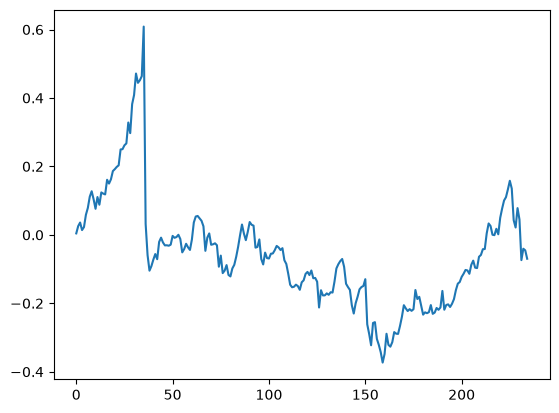

In [309]:
import matplotlib.pyplot as plt

plt.plot(daily_porto['cumulative_return'])

In [310]:
pos['weighted_return'].describe(include='all')

count    1932.000000
mean        0.000020
std         0.013764
min        -0.340206
25%        -0.002778
50%         0.000000
75%         0.003475
max         0.074742
Name: weighted_return, dtype: float64

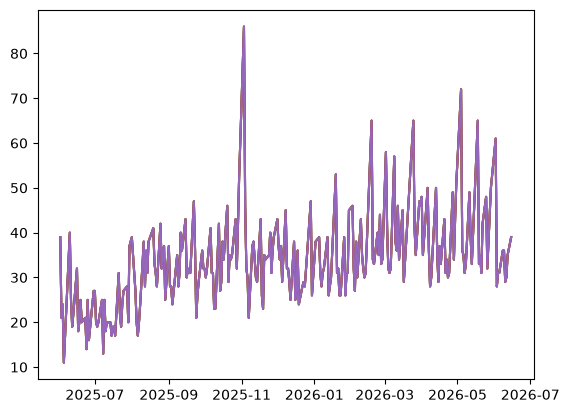

In [301]:
plt.plot(stock_day_sentiment.groupby('market_date').count())

In [311]:
daily_porto['long_short_return'].describe(include='all')

count    235.000000
mean       0.000583
std        0.039920
min       -0.358489
25%       -0.012057
50%        0.004360
75%        0.020607
max        0.098894
Name: long_short_return, dtype: float64